# Project Overview: Viet Nam Education & Economy (2011-2024)

## Dataset Overview
This dataset is a specialized extract from the World Bank’s World Development Indicators (WDI). It focuses on the intersection of Viet Nam's economic growth and its educational system's performance. The objective is to facilitate data visualization and correlation analysis to determine how national wealth, income distribution, and government spending influence literacy, enrollment, and long-term academic attainment.

## Data Structure
| Attribute | Details |
| :--- | :--- |
| **Total Variables** | 91 |
| **Time Frame** | 2011 - 2024 |
| **Regional Focus** | Viet Nam |
| **Key Categories** | Economics (GDP/GNI), Poverty & Equity, Education Quality, Gender Parity, and Attainment Levels. |
| **Missing Data Handling** | Usage of Interpolation and Omission for missing data |
| **Primary Units** | %, Constant 2015 US$, Ratios, and Numerical Counts. |

## Import libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Load analytical data

In [22]:
subfolder = "data/"

raw_filenames = [
    "2011-2017.csv", "2011-2018.csv", "2011-2021.csv", 
    "2011-2022-even.csv", "2011-2022.csv", "2011-2023.csv", 
    "2011-2024.csv", "2013-2018.csv", "2013-2024.csv", 
    "2014-2018.csv", "2014-2023.csv", "2014-2024.csv", 
    "2015-2022.csv", "2019-2023.csv"
]

file_list_with_path = [subfolder + f for f in raw_filenames]

class VietnamDataBody:
    def __init__(self, file_paths):
        self.file_paths = file_paths
        self.full_df = pd.DataFrame()
        self.data_map = {}
        self._build_data_body()

    def _build_data_body(self):
        all_frames = []
        for path in self.file_paths:
            try:
                df = pd.read_csv(path, skipfooter=5, engine='python')
                
                df.columns = [c.split(' [')[0] if ' [' in c else c for c in df.columns]
                df = df.drop(columns=['Country Name', 'Country Code', 'Series Code'], errors='ignore')
                
                all_frames.append(df)
            except FileNotFoundError:
                print(f"Error: Could not find file at {path}. Check your subfolder name.")
            except Exception as e:
                print(f"Error processing {path}: {e}")

        if all_frames:
            combined = pd.concat(all_frames, axis=0, ignore_index=True)
            self.full_df = combined.groupby('Series Name').first()
            self.full_df = self.full_df.replace('..', np.nan).apply(pd.to_numeric)
            self.data_map = self.full_df.to_dict(orient='index')

    def get(self, keyword):
        matches = [k for k in self.data_map.keys() if keyword.lower() in k.lower()]
        if not matches: return None
        return self.data_map[matches[0]] if len(matches) == 1 else {m: self.data_map[m] for m in matches}

# Init
data_body = VietnamDataBody(file_list_with_path)

# Check
print("Data loaded successfully. Total indicators:", len(data_body.full_df))

Data loaded successfully. Total indicators: 91


In [23]:
def extract_indicator_metadata(data_body):
    metadata_list = []
    
    for indicator_name, row in data_body.full_df.iterrows():
        valid_values = row.dropna()
        
        if not valid_values.empty:
            years = valid_values.index.astype(int)
            year_range = f"{years.min()}-{years.max()}"
            
            # 3. Calculate Stats
            mean_val = np.round(valid_values.mean(), 2)
            std_val = np.round(valid_values.std(), 2)
            

            if "index" in indicator_name.lower() or "ratio" in indicator_name.lower() or "%" in indicator_name:
                attr_type = "Quantitative (Continuous)"
            else:
                attr_type = "Quantitative (Discrete/Count)"
                
            dtype = "Real Value"
        else:
            year_range = "N/A"
            mean_val = "N/A"
            std_val = "N/A"
            attr_type = "N/A"
            dtype = "N/A"

        metadata_list.append({
            "Data Name": indicator_name,
            "Data Type": dtype,
            "Attribute": attr_type,
            "Year Range": year_range,
            "Mean": mean_val,
            "Std Dev": std_val
        })

    metadata_df = pd.DataFrame(metadata_list)
    return metadata_df

summary_table = extract_indicator_metadata(data_body)

# Verify
# print(summary_table.head(10))

# Full
print(summary_table.to_string())

                                                                                                   Data Name   Data Type                      Attribute Year Range          Mean       Std Dev
0                                                             Adjusted net national income (annual % growth)  Real Value      Quantitative (Continuous)  2011-2021  6.670000e+00  2.730000e+00
1                                                           Adjusted net national income (constant 2015 US$)  Real Value  Quantitative (Discrete/Count)  2011-2021  2.157671e+11  4.745323e+10
2                                                Adjusted net national income per capita (constant 2015 US$)  Real Value  Quantitative (Discrete/Count)  2011-2021  2.284080e+03  4.189700e+02
3                                     Adjusted net savings, excluding particulate emission damage (% of GNI)  Real Value      Quantitative (Continuous)  2011-2021  1.855000e+01  1.390000e+00
4                                     Adjuste

## Statistical Analysis of the WDI Data:


| Data Name | Data Type | Attribute	| Year Range | Mean	| Std Dev |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Adjusted net national income (annual % growth) | Real Value | Quantitative (Continuous) | 2011-2021 | 6.67 | 2.73 |
| Adjusted net national income (constant 2015 US$) | Real Value | Quantitative (Discrete) | 2011-2021 | 215.77B | 47.45B |
| Adjusted net national income per capita (constant 2015 US$) | Real Value | Quantitative (Discrete) | 2011-2021 | 2,284.08 | 418.97 |
| Adjusted net savings, excluding emissions (% of GNI) | Real Value | Quantitative (Continuous) | 2011-2021 | 18.55 | 1.39 |
| Adjusted net savings, including emissions (% of GNI) | Real Value | Quantitative (Continuous) | 2011-2021 | 18.20 | 1.40 |
| Adolescents out of school (% of secondary age) | Real Value | Quantitative (Continuous) | 2014-2023 | 6.17 | 2.71 |
| Adolescents out of school, female (%) | Real Value | Quantitative (Continuous) | 2014-2023 | 7.17 | 2.12 |
| Adolescents out of school, male (%) | Real Value | Quantitative (Continuous) | 2014-2023 | 5.20 | 3.34 |
| Children out of school (% of primary age) | Real Value | Quantitative (Continuous) | 2014-2024 | 1.27 | 0.72 |
| Children out of school, primary (count) | Real Value | Quantitative (Discrete) | 2014-2024 | 105,716.5 | 63,123.4 |
| Compulsory education, duration (years) | Real Value | Quantitative (Continuous) | 2011-2024 | 9.71 | 0.47 |
| Ed. Attainment: Doctoral, female (%) | Real Value | Quantitative (Continuous) | 2019-2023 | 0.04 | 0.01 |
| Ed. Attainment: Doctoral, male (%) | Real Value | Quantitative (Continuous) | 2019-2023 | 0.10 | 0.01 |
| Ed. Attainment: Bachelor's, total (%) | Real Value | Quantitative (Continuous) | 2019-2023 | 10.74 | 0.62 |
| Ed. Attainment: Master's, total (%) | Real Value | Quantitative (Continuous) | 2019-2023 | 0.68 | 0.04 |
| Ed. Attainment: Lower Secondary, total (%) | Real Value | Quantitative (Continuous) | 2019-2023 | 64.77 | 1.75 |
| Ed. Attainment: Primary, total (%) | Real Value | Quantitative (Continuous) | 2011-2023 | 82.60 | 3.52 |
| Ed. Attainment: Upper Secondary, total (%) | Real Value | Quantitative (Continuous) | 2011-2023 | 31.99 | 4.99 |
| GDP (constant 2015 US$) | Real Value | Quantitative (Discrete) | 2011-2024 | 285.63B | 69.60B |
| GDP growth (annual %) | Real Value | Quantitative (Continuous) | 2011-2024 | 6.10 | 1.69 |
| GDP per capita (constant 2015 US$) | Real Value | Quantitative (Discrete) | 2011-2024 | 2,974.24 | 601.11 |
| GNI growth (annual %) | Real Value | Quantitative (Continuous) | 2011-2024 | 6.58 | 2.95 |
| Gini index | Real Value | Quantitative (Continuous) | 2012-2022 | 35.72 | 0.69 |
| Gov expenditure on education (% of GDP) | Real Value | Quantitative (Continuous) | 2011-2022 | 3.50 | 0.52 |
| Gov expenditure on education (% of gov exp) | Real Value | Quantitative (Continuous) | 2011-2022 | 16.20 | 1.45 |
| Income share held by lowest 20% | Real Value | Quantitative (Continuous) | 2012-2022 | 6.87 | 0.21 |
| Income share held by highest 20% | Real Value | Quantitative (Continuous) | 2012-2022 | 42.95 | 0.59 |
| Multidimensional poverty headcount (%) | Real Value | Quantitative (Continuous) | 2012-2022 | 3.32 | 1.40 |
| Over-age students, primary (%) | Real Value | Quantitative (Continuous) | 2011-2018 | 2.22 | 0.90 |
| Poverty headcount ratio at $3.00/day (%) | Real Value | Quantitative (Continuous) | 2012-2022 | 2.45 | 0.96 |
| Poverty headcount ratio at $8.30/day (%) | Real Value | Quantitative (Continuous) | 2012-2022 | 29.50 | 9.31 |
| Primary education, pupils (count) | Real Value | Quantitative (Discrete) | 2011-2024 | 8.10M | 786,221 |
| Pupil-teacher ratio, primary | Real Value | Quantitative (Continuous) | 2011-2018 | 19.49 | 0.42 |
| Repeaters, primary, total (%) | Real Value | Quantitative (Continuous) | 2011-2018 | 1.03 | 0.25 |
| School enrollment, preprimary (% gross) | Real Value | Quantitative (Continuous) | 2011-2021 | 87.96 | 8.21 |
| School enrollment, primary (% gross) | Real Value | Quantitative (Continuous) | 2011-2021 | 103.29 | 1.25 |
| School enrollment, tertiary (% gross) | Real Value | Quantitative (Continuous) | 2011-2017 | 27.62 | 2.37 |
| Trained teachers in primary education (%) | Real Value | Quantitative (Continuous) | 2014-2024 | 93.55 | 9.17 |
| Trained teachers in preprimary, male (%) | Real Value | Quantitative (Continuous) | 2014-2024 | 82.48 | 16.33 |

## Extract metadata description

In [24]:
metadata_files = [subfolder + f.replace(".csv", "-meta.csv") for f in raw_filenames]

class VietnamMetadataExtractor:
    def __init__(self, metadata_paths):
        self.metadata_paths = metadata_paths
        self.descriptions = {}
        self._extract_all_metadata()

    def _extract_all_metadata(self):
        """Iterates through meta files to find the Indicator Name and Long Definition."""
        for path in self.metadata_paths:
            try:
                start_line = -1
                with open(path, 'r', encoding='utf-8') as f:
                    for i, line in enumerate(f):
                        if "Indicator Name,Long definition" in line or "Code,License Type" in line:
                            start_line = i
                            break
                
                if start_line != -1:

                    meta_df = pd.read_csv(path, skiprows=start_line)
                    for _, row in meta_df.iterrows():
                        name = str(row['Indicator Name']).strip()
                        defn = str(row['Long definition']).strip()
                        if name and defn:
                            self.descriptions[name] = defn
            except Exception as e:
                continue

    def get_description(self, indicator_name):
        return self.descriptions.get(indicator_name, "Description not found in metadata files.")

# Init
meta_extractor = VietnamMetadataExtractor(metadata_files)

def extract_comprehensive_summary(data_body, meta_extractor):
    combined_list = []
    
    for indicator_name, row in data_body.full_df.iterrows():
        valid_values = row.dropna()
        
        if not valid_values.empty:
            years = valid_values.index.astype(int)
            year_range = f"{years.min()}-{years.max()}"
            mean_val = np.round(valid_values.mean(), 2)
            std_val = np.round(valid_values.std(), 2)
            
            # Logic
            low_name = indicator_name.lower()
            if any(x in low_name for x in ["index", "ratio", "%", "growth", "per capita"]):
                attr_type = "Quantitative (Continuous)"
            else:
                attr_type = "Quantitative (Discrete)"
            
            # Fetch
            description = meta_extractor.get_description(indicator_name)
            
            combined_list.append({
                "Data Name": indicator_name,
                "Description": description,
                "Data Type": "Real Value",
                "Attribute": attr_type,
                "Year Range": year_range,
                "Mean": mean_val,
                "Std Dev": std_val
            })

    return pd.DataFrame(combined_list)

final_summary = extract_comprehensive_summary(data_body, meta_extractor)

print(f"Extracted info for {len(final_summary)} indicators.")
final_summary[['Data Name', 'Description']]

# final_summary[['Data Name', 'Description', 'Attribute']]

Extracted info for 91 indicators.


,Data Name,Description
0,Adjusted net national income (annual % growth),Adjusted net national income is GNI minus cons...
1,Adjusted net national income (constant 2015 US$),Adjusted net national income is GNI minus cons...
2,Adjusted net national income per capita (const...,Adjusted net national income is GNI minus cons...
3,"Adjusted net savings, excluding particulate em...",Adjusted net savings are equal to net national...
4,"Adjusted net savings, including particulate em...",Adjusted net savings are equal to net national...
...,...,...
86,"Trained teachers in preprimary education, fema...",Trained teachers in preprimary education are t...
87,"Trained teachers in preprimary education, male...",Trained teachers in preprimary education are t...
88,Trained teachers in primary education (% of to...,Trained teachers in primary education are the ...
89,"Trained teachers in primary education, female ...",Trained teachers in primary education are the ...


## Metadata Analysis of the Metrics (2011-2024)

| Data Group | Description |
| :--- | :--- | 
| **Adjusted net national income (annual % growth)** | Adjusted net national income is GNI minus consumption of fixed capital and natural resources depletion. This indicator denotes the percentage change over each previous year of the constant price (base year 2015) series in United States dollars. |
| **Adjusted net national income (constant 2015 US$)** | Adjusted net national income is GNI minus consumption of fixed capital and natural resources depletion, expressed in constant 2015 US dollars. |
| **Adjusted net national income per capita (constant 2015 US$)** | The adjusted net national income divided by the midyear population, adjusted for inflation using the 2015 base year. |
| **Adjusted net savings, excluding/including particulate emission damage (% of GNI)** | Net national savings plus education expenditure minus energy, mineral, and forest depletion, and damage from carbon dioxide and particulate emissions. |
| **Adolescents out of school (% of lower secondary school age)** | Percentage of lower secondary school age adolescents who are not enrolled in any level of education. |
| **Children out of school (% of primary school age)** | Percentage of primary-school-age children not enrolled in primary or secondary school. |
| **Compulsory education, duration (years)** | The total number of years that children are legally required to attend school. |
| **Educational attainment (Doctoral, Master's, Bachelor's, etc.)** | The cumulative percentage of the population aged 25+ that has attained or completed a specific level of education (e.g., Primary, Lower/Upper Secondary, or Tertiary degrees). |
| **GDP (constant 2015 US$)** | The total market value of all final goods and services produced within a country in a given period, adjusted for inflation using 2015 as the base year. |
| **GDP growth (annual %)** | Annual percentage growth rate of GDP at market prices based on constant local currency. |
| **GDP per capita (constant 2015 US$)** | Gross domestic product divided by midyear population, expressed in constant 2015 US dollars. |
| **GNI growth (annual %)** | Annual percentage growth rate of GNI (Gross National Income) based on constant local currency. |
| **Gini index** | Measures the extent to which the distribution of income (or consumption expenditure) among individuals or households deviates from a perfectly equal distribution ($0$ = perfect equality, $100$ = perfect inequality). |
| **Government expenditure on education (% of GDP / % of gov. exp)** | Total general government expenditure on education expressed as a percentage of the nation's GDP or as a percentage of total government spending. |
| **Income share held by lowest/highest/middle 20%** | The percentage of total national income that accrues to specific quintiles of the population, ranging from the poorest $20\%$ to the wealthiest $20\%$. |
| **Multidimensional poverty headcount ratio (%)** | The percentage of the population living in households that are multidimensionally poor, based on deprivations in health, education, and living standards. |
| **Over-age students, primary (%)** | The percentage of enrolled students who are older than the official school-age range for primary education. |
| **Poverty headcount ratio at $3.00 / $4.20 / $8.30 a day** | Percentage of the population living on less than the specified amount per day at 2021 purchasing power parity (PPP). |
| **Primary education, pupils** | Total number of students enrolled in primary education, regardless of age. |
| **Pupil-teacher ratio (Preprimary, Primary, Secondary)** | The average number of pupils per teacher at the specified level of education. |
| **Repeaters, primary (% of enrollment)** | The percentage of students in primary education who are enrolled in the same grade as the previous year. |
| **School enrollment, preprimary / primary / secondary / tertiary (% gross)** | Total enrollment in a specific level of education, regardless of age, expressed as a percentage of the population in the official age group for that level. |
| **Trained teachers in education (% of total teachers)** | Percentage of teachers at a specific level who have received at least the minimum organized teacher training required for teaching in the country. |

## Handle missing data


There are 2 regions within the data set that contains missing data:
- In the field of Educational attainment, at least completed primary, population 25+ years, female (%) (cumulative), there exists 1 missing data point in 2018.
- In the field of Trained teachers, there is a cluster of missing values affecting both the Preprimary and Primary education series during the years 2016 and 2017.

- Trained teachers in preprimary education, female (%) and male (%) both lack records for the consecutive years 2016 and 2017.

- Trained teachers in primary education, female (%) and male (%) both lack records for the year 2017.

Upon further observation, we can identify the appropriate method to fill in the missing data in Educational attainment (female) based on the male and total counterparts:
- For Education attainment, at least completed primary, population 25+ years, male (%), we can observe a noticable increase in value after 2018, where before that it was stable (from 2016 to 2018: $85.67 \%, 85.58 \%, 85.66 \%$) until 2019, where it jumped to $91.15 \%$, increasing by approximately $5.5 \%$.
- For Education attainment, at least completed primary, population 25+ years, total (%), we can also observe a noticable increase in value after 2018, where before that it was stable (from 2016 to 2018: $81.44 \%, 81.39 \%, 81.35 \%$) until 2019, where it jumped to $88.63 \%$, increasing by approximately $7.3 \%$.
- The same gap can be found from the values around the missing record within the field of Education attainment, at least completed primary, population 25+ years, female (%), where it was stable from 2016 to 2017: $77.56 \%, 77.50 \%$, but increased significantly in 2019: $86.27 \%$, it is reasonable to assume that the missing record in 2018 will follow along with the general trend of its similar fields. The record will be filled in using Linear Interpolation, following the assumption that the value remains stable before 2018, until 2019 where a noticable spike happened in all fields.

In [25]:
# Find
target_female = "Educational attainment, at least completed primary, population 25+ years, female (%) (cumulative)"
comparison_group = [
    "Educational attainment, at least completed primary, population 25+ years, total (%) (cumulative)",
    "Educational attainment, at least completed primary, population 25+ years, male (%) (cumulative)",
    target_female
]
years_context = ["2016", "2017", "2018", "2019"]

print("--- Data Before Interpolation (2018 is NaN) ---")
print(data_body.full_df.loc[[target_female], years_context])

data_body.full_df.loc[target_female] = data_body.full_df.loc[target_female].interpolate(method='linear')

# Demonstrate
print("\n--- Data After Interpolation (2018 Filled) ---")
print(data_body.full_df.loc[[target_female], years_context])

--- Data Before Interpolation (2018 is NaN) ---
                                                        2016      2017  2018  \
Series Name                                                                    
Educational attainment, at least completed prim...  77.56308  77.50417   NaN   

                                                         2019  
Series Name                                                    
Educational attainment, at least completed prim...  86.269997  

--- Data After Interpolation (2018 Filled) ---
                                                        2016      2017  \
Series Name                                                              
Educational attainment, at least completed prim...  77.56308  77.50417   

                                                        2018       2019  
Series Name                                                              
Educational attainment, at least completed prim...  78.65073  86.269997  


## Handle missing data
While the gap in Educational Attainment was resolved through interpolation, a different approach is required for the Trained Teacher series. In this instance, the missing records in 2016 and 2017 will be handled using Omission.

Unlike the linear growth patterns observed in attainment, the teacher quality data lacks a consistent proxy or a clear mathematical trend during the missing years. Specifically:

- Preprimary Gap (2016-2017): Both female and male teacher data are missing for two consecutive years. Attempting to interpolate over a 24-month gap without a stable secondary variable (like enrollment) could introduce significant statistical noise.

- Primary Gap (2017): While only one year is missing, the values for "Trained teachers" often fluctuate based on specific annual government certification drives or policy changes that do not follow a linear progression.

Since these specific years lack a "stable" baseline that mirrors other fields, omitting these specific data points ensures that our final correlation analysis (linking education quality to economic growth) relies only on verified, empirical records provided by the World Bank.

In [26]:
# Identify 
teacher_indicators = [
    "Trained teachers in preprimary education, female (% of female teachers)",
    "Trained teachers in preprimary education, male (% of male teachers)",
    "Trained teachers in primary education, female (% of female teachers)",
    "Trained teachers in primary education, male (% of male teachers)"
]

gap_years = ["2016", "2017"]

# Omit
cleaned_teacher_data = data_body.full_df.loc[teacher_indicators].drop(columns=gap_years)

print("--- Data Summary after Omission (2016-2017) ---")
print(f"Columns remaining: {list(cleaned_teacher_data.columns)}")
print("\nSample of Omitted Output:")
print(cleaned_teacher_data[["2015", "2018"]])

--- Data Summary after Omission (2016-2017) ---
Columns remaining: ['2011', '2012', '2013', '2014', '2015', '2018', '2020', '2019', '2021', '2022', '2023', '2024']

Sample of Omitted Output:
                                                         2015       2018
Series Name                                                             
Trained teachers in preprimary education, femal...  98.704971  99.172944
Trained teachers in preprimary education, male ...  96.612105  96.737589
Trained teachers in primary education, female (...  99.611684  99.900909
Trained teachers in primary education, male (% ...  99.006954  99.752261


## Analytical Plan -  Question List
To provide a multidimensional view of Viet Nam's development from 2011 to 2024, the following questions are used to further analyze and make conclusions of Vietnam's Economic and Education growth:

1. Economic Trajectory: How has Viet Nam’s GDP and GNI growth fluctuated over the last decade, and do they mirror each other's volatility?

2. The Wealth-Education Correlation: Is there a measurable correlation between GDP per capita and the percentage of the population attaining Bachelor’s degrees?

3. Income Inequality Mapping: How has the gap between the income share held by the highest 20% and the lowest 20% evolved in relation to the Gini Index?

4. Educational Resource Allocation: How does the government prioritize education relative to its total budget compared to the education sector's share of the national GDP?

5. Gender Parity in Out-of-School Adolescents: What is the gender distribution among adolescents out of school, and has the female-to-male ratio improved over time?

6. Teacher Qualification Standards: How do training levels compare across different educational tiers (Preprimary vs. Primary), and where is the greatest variance in teacher quality?

7. Efficiency of Primary Education: Is there a relationship between the Pupil-Teacher ratio and the percentage of repeaters in primary school?

8. Poverty Threshold Analysis: How does the headcount ratio change when shifting the poverty definition from $3.00/day to $8.30/day across the timeline?

9. High-Level Attainment Composition: What is the proportional breakdown of postgraduate attainment (Master's vs. Doctoral) within the 25+ population?

10. Savings and Environmental Cost: How much of Viet Nam's national savings is "lost" to particulate emission damage when comparing adjusted net savings?

11. Early Childhood Education Momentum: Has the growth in preprimary school enrollment kept pace with the increase in adjusted net national income?

12. Multidimensional vs. Monetary Poverty: Does the Multidimensional Poverty index follow the same downward trajectory as the $3.00/day poverty headcount?

## Plot Preparation

In [86]:
# 1. Economic Trajectory: GDP vs GNI Growth
# Range: 2011-2024
# Data: GDP growth (annual %), GNI growth (annual %)
# Line Chart
def plot_q1(data_body):
    years = [str(y) for y in range(2011, 2025)]
    
    gdp_growth = data_body.full_df.loc["GDP growth (annual %)", years].astype(float)
    gni_growth = data_body.full_df.loc["GNI growth (annual %)", years].astype(float)
    
    plt.figure(figsize=(12, 6))
    plt.plot(years, gdp_growth, marker='o', markersize=6, color='#1f77b4', 
             linewidth=2, label='GDP Growth (%)')
    plt.plot(years, gni_growth, marker='s', markersize=6, color='#d62728', 
             linewidth=2, linestyle='--', label='GNI Growth (%)')
    
    plt.title("Q1: GDP vs. GNI Annual Growth Trajectory (2011-2024)", fontsize=14)
    plt.ylabel("Annual Growth Rate (%)", fontsize=12)
    plt.xlabel("Year", fontsize=12)
    
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    
    plt.xticks(rotation=45)
    plt.legend(frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# 2. Wealth-Education Correlation
# Range: 2019-2023
# Data: GDP per capita (constant 2015 US$), Bachelor's degree attainment (%)
# Scatter Plot with Linear Regression Line and Residuals
def plot_q2(data_body):
    years = [str(y) for y in range(2019, 2024)]
    gdp_key = "GDP per capita (constant 2015 US$)"
    bach_key = [i for i in data_body.full_df.index if "Bachelor's" in i and "total" in i][0]

    x = data_body.full_df.loc[gdp_key, years].values.astype(float)
    y = data_body.full_df.loc[bach_key, years].values.astype(float)
    
    m, c = np.polyfit(x, y, 1)
    y_pred = m * x + c
    
    plt.figure(figsize=(10, 6))
    
    for i in range(len(x)):
        plt.plot([x[i], x[i]], [y[i], y_pred[i]], color='gray', linestyle='--', alpha=0.6, zorder=1)
        plt.text(x[i] + 5, y[i] + 0.05, years[i], fontsize=10, fontweight='bold', zorder=4)

    plt.plot(x, y_pred, color='red', linewidth=2, label=f'Regression (y={m:.4f}x + {c:.2f})', zorder=2)
    plt.scatter(x, y, color='#1f77b4', s=120, edgecolors='white', label='Annual Data', zorder=3)
    
    # Formatting
    plt.title("Q2: Wealth vs. Bachelor's Attainment (2019-2023)\nRegression with Residual (Loss) Lines and Year Labels")
    plt.xlabel("GDP per Capita (Constant 2015 US$)")
    plt.ylabel("Bachelor's Attainment (%)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def print_regression_q2(data_body):
    years = [str(y) for y in range(2019, 2024)]
    gdp_key = "GDP per capita (constant 2015 US$)"
    bach_key = [i for i in data_body.full_df.index if "Bachelor's" in i and "total" in i][0]

    x = data_body.full_df.loc[gdp_key, years].values.astype(float)
    y = data_body.full_df.loc[bach_key, years].values.astype(float)
    
    m, c = np.polyfit(x, y, 1)
    print(f"Q2 Regression Equation: y = {m:.4f}x + {c:.2f}")

# 3. Income Inequality Mapping
# Range: 2012-2022 (Even Years Only)
# Data: Income share held by highest 20%, Income share held by lowest 20%
# Stacked Area Chart
def plot_q3(data_body):
    even_years = [str(y) for y in range(2012, 2023, 2)]
    high_20 = data_body.full_df.loc["Income share held by highest 20%", even_years].values.astype(float)
    low_20 = data_body.full_df.loc["Income share held by lowest 20%", even_years].values.astype(float)
    
    plt.figure()
    plt.fill_between(even_years, high_20, label='Highest 20% Share', color='#ff7f0e', alpha=0.4)
    plt.fill_between(even_years, low_20, label='Lowest 20% Share', color='#2ca02c', alpha=0.7)
    plt.title("Q3: Income Inequality Distribution (Even Years: 2012-2022)")
    plt.ylabel("Percentage of Total National Income")
    plt.legend(loc='center right')
    plt.show()

# 4. Educational Resource Allocation
# Range: 2011-2022 (Sample Years: 2011, 2014, 2017, 2020, 2022)
# Data: Government expenditure on education (% of GDP), Government expenditure on education (% of government expenditure)
# Grouped Bar Chart
def plot_q4(data_body):
    years_sample = ["2011", "2014", "2017", "2020", "2022"]
    edu_gdp = data_body.full_df.loc["Government expenditure on education, total (% of GDP)", years_sample].values.astype(float)
    edu_gov = data_body.full_df.loc["Government expenditure on education, total (% of government expenditure)", years_sample].values.astype(float)
    
    x = np.arange(len(years_sample))
    width = 0.35
    
    fig, ax = plt.subplots()
    ax.bar(x - width/2, edu_gdp, width, label='% of GDP', color='#1f77b4')
    ax.bar(x + width/2, edu_gov, width, label='% of Total Gov Exp', color='#aec7e8')
    
    ax.set_ylabel('Percentage (%)')
    ax.set_title('Q4: Education Expenditure Allocation (2011-2022)')
    ax.set_xticks(x)
    ax.set_xticklabels(years_sample)
    ax.legend()
    plt.show()

# 5. Gender Parity in Out-of-School Adolescents
# Range: 2014-2023
# Data: Adolescents out of school by gender (female %, male %)
# Stacked Bar Chart
def plot_q5(data_body):
    years = [str(y) for y in range(2014, 2024)]
    
    f_label = [i for i in data_body.full_df.index if "Adolescents out of school, female" in i][0]
    m_label = [i for i in data_body.full_df.index if "Adolescents out of school, male" in i][0]

    female = data_body.full_df.loc[f_label, years].astype(float)
    male = data_body.full_df.loc[m_label, years].astype(float)
    
    plt.figure()
    plt.bar(years, female, label='Female', color='#e377c2')
    plt.bar(years, male, bottom=female, label='Male', color='#1f77b4')
    plt.title(f"Q5: Out-of-School Adolescents by Gender\nSeries: {f_label.split('(')[0]}")
    plt.ylabel("Percentage (%)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

# 6. Teacher Qualification Standards
# Range: 2014-2024 (Note: 2016-2017 are Omitted as per missing data treatment plan)
# Data: Trained teachers in preprimary education (female %), Trained teachers in primary education (female %)
# Box Plot (Distribution Comparison)
def plot_q6(data_body):
    valid_years = ["2014", "2015", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]
    
    pre_key = [i for i in data_body.full_df.index if "Trained teachers in preprimary education, female" in i][0]
    pri_key = [i for i in data_body.full_df.index if "Trained teachers in primary education, female" in i][0]
    
    preprimary = data_body.full_df.loc[pre_key, valid_years].astype(float)
    primary = data_body.full_df.loc[pri_key, valid_years].astype(float)
    
    plt.figure(figsize=(10, 6))
    
    sns.boxplot(data=[preprimary, primary], palette="Set2", width=0.5)
    plt.ylim(80, 100.5)
    
    plt.xticks([0, 1], ['Preprimary', 'Primary'])
    plt.title("Q6: Variance in Female Teacher Training Levels (2014-2024)\n(Y-Axis Scaled from 80%)")
    plt.ylabel("Trained Teachers (%)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# 7. Efficiency of Primary Education
# Range: 2011-2018
# Data: Pupil-teacher ratio (primary), Repeaters in primary education (% of total enrollment)
# Scatter Plot with Trajectory Arrows (Time-Series Path)
def plot_q7(data_body):
    years = [str(y) for y in range(2011, 2019)]
    ratio = data_body.full_df.loc["Pupil-teacher ratio, primary", years].astype(float)
    repeaters = data_body.full_df.loc["Repeaters, primary, total (% of total enrollment)", years].astype(float)
    
    plt.figure(figsize=(11, 7))

    for i in range(len(years) - 1):
        style = '-' if years[i] == "2016" else '->'
        plt.annotate('', xy=(ratio.iloc[i+1], repeaters.iloc[i+1]), 
                     xytext=(ratio.iloc[i], repeaters.iloc[i]),
                     arrowprops=dict(arrowstyle=style, color='royalblue', lw=1.5, alpha=0.7))
    
    plt.scatter(ratio, repeaters, c=range(len(years)), cmap='viridis', s=120, edgecolors='white', zorder=3)
    
    for i, year in enumerate(years):
        if year == "2016":
            plt.text(ratio.iloc[i] - 0.02, repeaters.iloc[i] - 0.02, year, 
                     fontsize=9, fontweight='bold', ha='right')
        else:
            plt.text(ratio.iloc[i] + 0.02, repeaters.iloc[i] + 0.01, year, 
                     fontsize=9, fontweight='bold')

    plt.title("Q7: Primary Education Efficiency Trajectory (2011-2018)\nCollision Correction for 2016-2017")
    plt.xlabel("Pupil-Teacher Ratio (Primary)")
    plt.ylabel("Repeaters (%)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# 8. Poverty Threshold Analysis
# Range: 2012-2022 (Even Years)
# Data: Poverty headcount ratio at $3.00/day (2021 PPP), Poverty headcount ratio at $8.30/day (2021 PPP)
# Step Line Chart
def plot_q8(data_body):
    even_years = [str(y) for y in range(2012, 2023, 2)]
    p3 = data_body.full_df.loc["Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)", even_years].astype(float)
    p8 = data_body.full_df.loc["Poverty headcount ratio at $8.30 a day (2021 PPP) (% of population)", even_years].astype(float)
    
    plt.figure()
    plt.step(even_years, p3, where='mid', label='$3.00/day', marker='o')
    plt.step(even_years, p8, where='mid', label='$8.30/day', marker='s')
    plt.title("Q8: Poverty Headcount Trends by Threshold")
    plt.ylabel("Headcount Ratio (%)")
    plt.legend()
    plt.show()

# 9. High-Level Attainment Composition
# Range: 2019-2023
# Data: Master's degree attainment (%), Doctoral degree attainment (%) - Population 25+ years
# Pie Chart
def plot_q9(data_body):
    indicators = [
        "Educational attainment, at least Master's or equivalent, population 25+, total (%) (cumulative)",
        "Educational attainment, Doctoral or equivalent, population 25+, total (%) (cumulative)"
    ]
    
    plot_years = ["2019", "2021", "2022", "2023"]
    colors = ['#66b3ff', '#99ff99']
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, year in enumerate(plot_years):
        # Extract and convert values
        values = data_body.full_df.loc[indicators, year].astype(float)
        
        # Plot on the specific subplot axis
        axes[i].pie(values, labels=["Master's", "Doctoral"], 
                    autopct='%1.2f%%', colors=colors, startangle=140,
                    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
        
        axes[i].set_title(f"Composition in {year}", fontweight='bold')

    plt.suptitle("Q9: Comparative Composition of Postgraduate Attainment (2019-2023)", 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()

# 10. Savings and Environmental Cost
# Range: 2011-2021
# Data: Adjusted net savings excluding particulate emission damage (% of GNI), Adjusted net savings including particulate emission damage (% of GNI)
# Stacked Area Chart
def plot_q10(data_body):
    years = [str(y) for y in range(2011, 2022)]
    
    # Safely retrieve keys
    excl_key = "Adjusted net savings, excluding particulate emission damage (% of GNI)"
    incl_key = "Adjusted net savings, including particulate emission damage (% of GNI)"
    
    excl = data_body.full_df.loc[excl_key, years].astype(float)
    incl = data_body.full_df.loc[incl_key, years].astype(float)
    damage = excl - incl
    
    plt.figure(figsize=(10, 6))
    plt.stackplot(years, incl, damage, 
                  labels=['Net Savings (Including Damage)', 'Particulate Emission Damage'], 
                  colors=['#2ca02c', '#d62728'], alpha=0.6)
    
    plt.ylim(15, max(excl) + 1)
    
    plt.title("Q10: Impact of Particulate Emission Damage on Adjusted Net Savings\n(Y-Axis Scaled from 12.5%)")
    plt.ylabel("% of GNI")
    plt.xlabel("Year")
    plt.legend(loc='lower right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    avg_damage = damage.mean()
    print(f"Average GNI lost to Particulate Emission Damage (2011-2021): {avg_damage:.3f}%")

# 11. Early Childhood Education Momentum
# Range: 2011-2021
# Data: School enrollment in preprimary education (% gross), Adjusted net national income (constant 2015 US$)
# Dual-Axis Line Chart (Correlation of growth trends)
def plot_q11(data_body):
    years = [str(y) for y in range(2011, 2022)]
    enrollment = data_body.full_df.loc["School enrollment, preprimary (% gross)", years].astype(float)
    income = data_body.full_df.loc["Adjusted net national income (constant 2015 US$)", years].astype(float)
    
    fig, ax1 = plt.subplots()
    ax1.plot(years, enrollment, color='green', marker='o', label='Preprimary Enrollment')
    ax1.set_ylabel('Enrollment (%)', color='green')
    
    ax2 = ax1.twinx()
    ax2.plot(years, income, color='blue', linestyle='--', label='Net National Income')
    ax2.set_yscale('log')
    ax2.set_ylabel('Income (Log Scale)', color='blue')
    
    plt.title("Q11: Preprimary Enrollment vs. National Income")
    plt.show()

# 12. Multidimensional vs. Monetary Poverty
# Range: 2012-2022 (Even Years)
# Data: Multidimensional poverty headcount ratio (%), Poverty headcount ratio at $3.00/day (2021 PPP) (%)
# Multi-Series Line Chart
def plot_q12(data_body):
    even_years = [str(y) for y in range(2012, 2023, 2)]
    multi = data_body.full_df.loc["Multidimensional poverty headcount ratio (World Bank) (% of population)", even_years].astype(float)
    monetary = data_body.full_df.loc["Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)", even_years].astype(float)
    
    plt.figure()
    plt.plot(even_years, multi, label='Multidimensional', marker='h', color='purple')
    plt.plot(even_years, monetary, label='Monetary ($3.00/day)', marker='D', color='orange')
    plt.title("Q12: Multidimensional vs. Monetary Poverty Headcount")
    plt.ylabel("Percentage (%)")
    plt.legend()
    plt.show()

## Q1 - Economic Trajectory: GDP vs GNI Growth (2011-2024)

Question: How has Viet Nam’s GDP and GNI growth fluctuated over the last decade, and do they mirror each other's volatility?

Graph Used: Line Chart

A unified line chart is essential here because GDP and GNI are measured in identical units (annual % growth). By plotting them on a single y-axis rather than dual axes, we ensure a 1:1 visual comparison. We can also precisely identify the delta (the gap between the two lines) without the scale distortion that often occurs when using multiple axes for similar economic indicators.

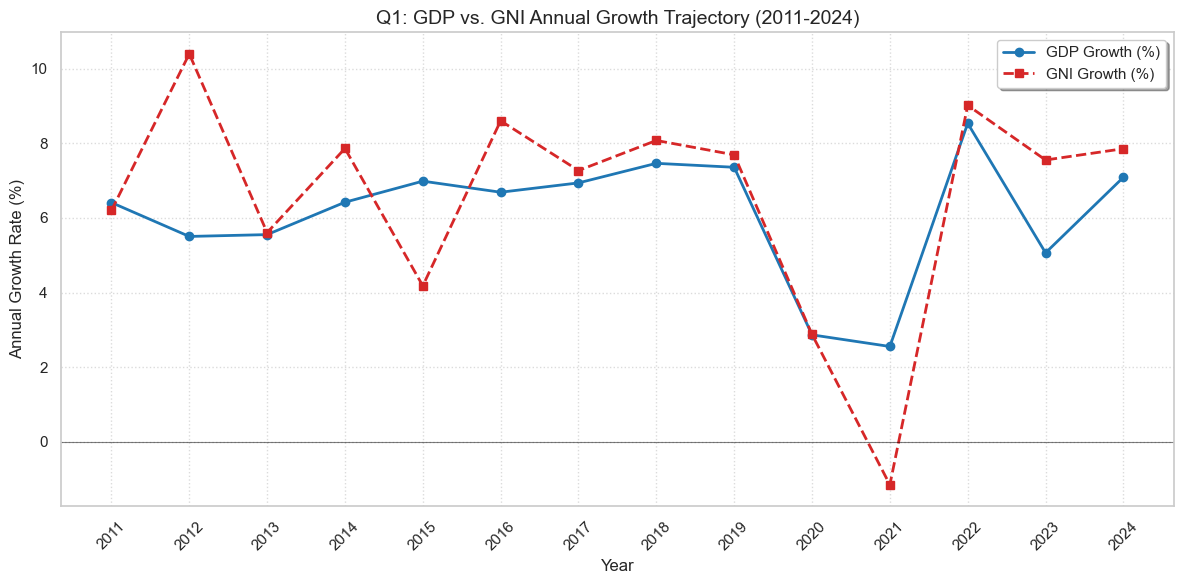

In [87]:
plot_q1(data_body)

**Graph Observations:**
- Both GDP and GNI maintained a similar growth rate throughout the 14 years period, showing similar trends. The line for GNI growth behaves more erratic than GDP growth, with higher deviation from year to year.
- The delta gap between GDP and GNI growth is roughly $4\%$ in 2012 and 2021, otherwise, the gap fluctuates between $0-2\%$, further reinforcing their similarity.
- Both lines take a noticable dive after 2019, with GDP growth only at slightly higher than $2\%$ in 2021 while GNI growth experiences a deeper dip, with negative values in the same year ($-1\%$) in the same year. GNI growth in 2021 is the only instance of negative growth or decay within the 14-year span.
- After the dive in 2019-2021, both growth rates make a full recovery starting from 2022 (slightly higher than $8\%$), even higher than before the dive in 2019. The general trend after 2022 remains stable after that, with the highest growth rate in that time span be in 2022 as well.

**Key Conclusions:**
- GDP and GNI growth rates moved in synchronization, this suggests that the factors driving domestic production are the primary drivers of national income through out the decades.
- An economic shock happened in Vietnam during 2019-2021 that had impacted the economy, stunting growth heavily.
- The sharp rebound in 2022 demonstrates high economic elasticity. Despite the severe contraction in 2021, the economy did not stagnate but returned to its pre-shock growth corridor by 2023.

## Q2 - Wealth-Education Correlation (2019-2023)

Question: Is there a measurable correlation between GDP per capita and the percentage of the population attaining Bachelor's degrees?

Graph Used: Scatter Plot with Linear Regression Line

Beyond showing simple correlation, the addition of vertical residual (loss) lines from each data point to the regression line is critical for identifying outliers. It visualizes the variance—showing which years Viet Nam achieved higher educational results than its economic level would typically predict, or vice versa.

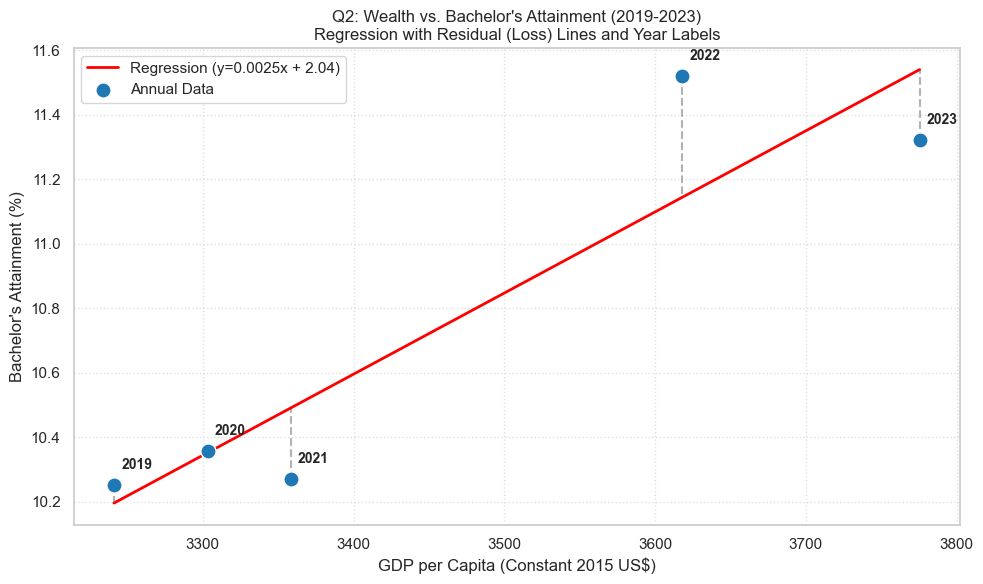

In [88]:
plot_q2(data_body)

In [89]:
print_regression_q2(data_body)

Q2 Regression Equation: y = 0.0025x + 2.04


**Graph Observations:**

[Observations to be filled in later]

**Key Conclusions:**

[Conclusions to be filled in later]

## Q3 - Income Inequality Mapping (2012-2022)

Question: How has the gap between the income share held by the highest 20% and the lowest 20% evolved in relation to the Gini Index?

Graph Used: Stacked Area Chart

An area chart is used to visualize the economic imbalance. By layering the income share of the top 20% over the bottom 20%, the size difference between the shaded regions represents the scale of inequality.

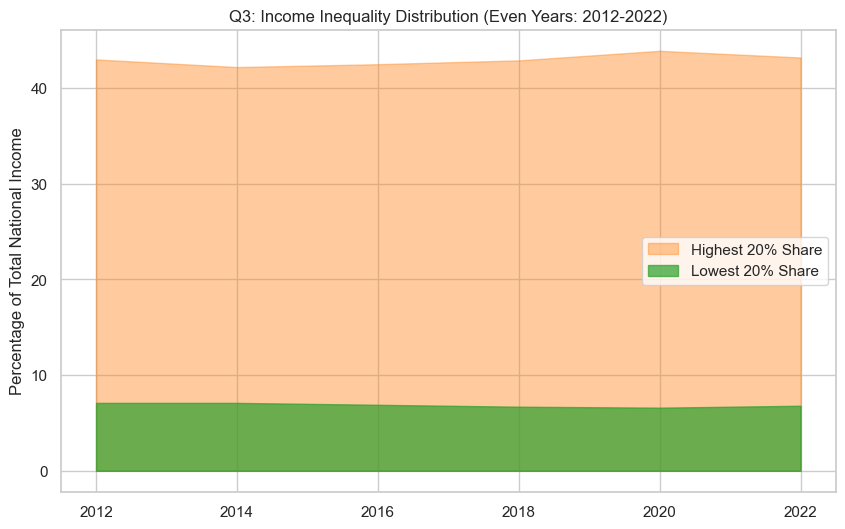

In [90]:
plot_q3(data_body)

**Graph Observations:**

[Observations to be filled in later]

**Key Conclusions:**

[Conclusions to be filled in later]

## Q4 - Educational Resource Allocation (2011-2022)

Question: How does the government prioritize education relative to its total budget compared to the education sector's share of the national GDP?

Graph Used: Grouped Bar Chart

Using grouped bars allows for a side-by-side comparison of two distinct metrics with the same scale (%). From there, we can distinguish between a growing economy naturally spending more (GDP) versus a deliberate policy shift where the government chooses to give education better expenditure.

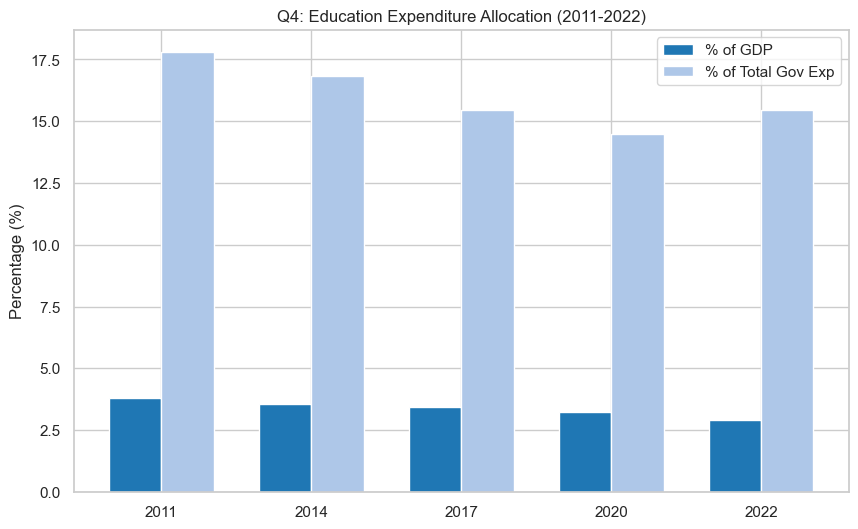

In [91]:
plot_q4(data_body)

**Graph Observations:**

[Observations to be filled in later]

**Key Conclusions:**

[Conclusions to be filled in later]

## Q5 - Gender Parity in Out-of-School Adolescents (2014-2023)

Question: What is the gender distribution among adolescents out of school, and has the female-to-male ratio improved over time?

Graph Used: Stacked Bar Chart

A stacked bar chart is used to emphasize the composition of the problem. It allows us to track two things simultaneously: the total volume of out-of-school adolescents and the shifting internal ratio of males to females. This makes it immediately obvious if a reduction in the total number is benefiting one gender more significantly than the other.

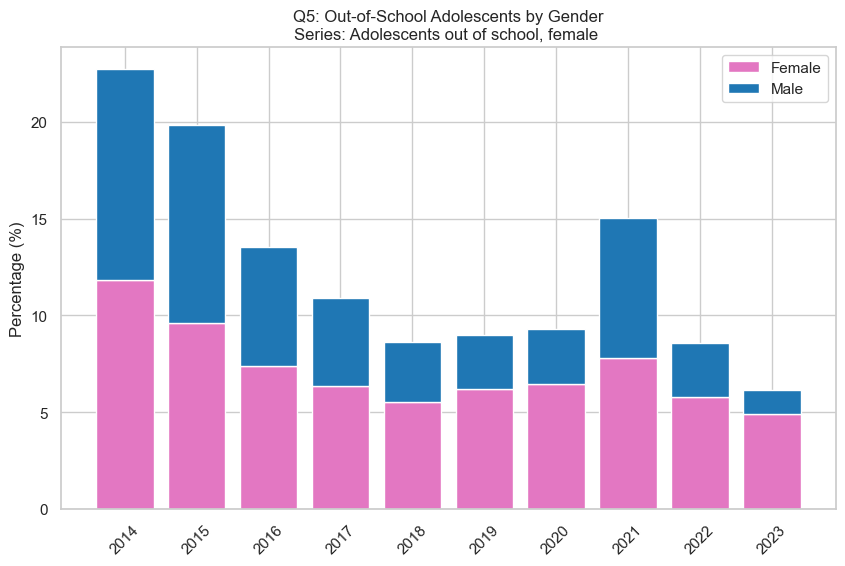

In [92]:
plot_q5(data_body)

**Graph Observations:**

[Observations to be filled in later]

**Key Conclusions:**

[Conclusions to be filled in later]

## Q6 - Teacher Qualification Standards (2014-2024)

Question: How do training levels compare across different educational tiers (Preprimary vs. Primary), and where is the greatest variance in teacher quality?

Graph Used: Box Plot

A standard chart here hides the true variance. By scaling the baseline properly, the boxplot amplifies the spread of the data, visualizing the consistency of training.

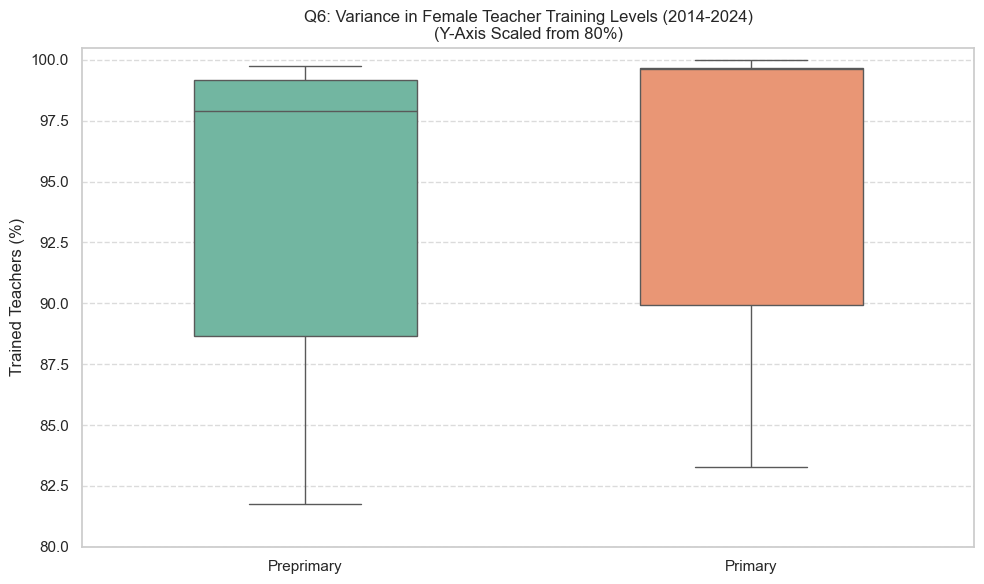

In [93]:
plot_q6(data_body)

**Graph Observations:**

[Observations to be filled in later]

**Key Conclusions:**

[Conclusions to be filled in later]

## Q7 - Efficiency of Primary Education (2011-2018)

Question: Is there a relationship between the Pupil-Teacher ratio and the percentage of repeaters in primary school?

Graph Used: Scatter Plot with Trajectory Arrows

A connected scatter plot is used to visualize the systemic momentum. Educational efficiency is a multi-year process, therefore, standard scatter points can look like a random cloud. Connecting them allows us to see the trajectory of the system, tracing the general Viet Nam is moving toward.

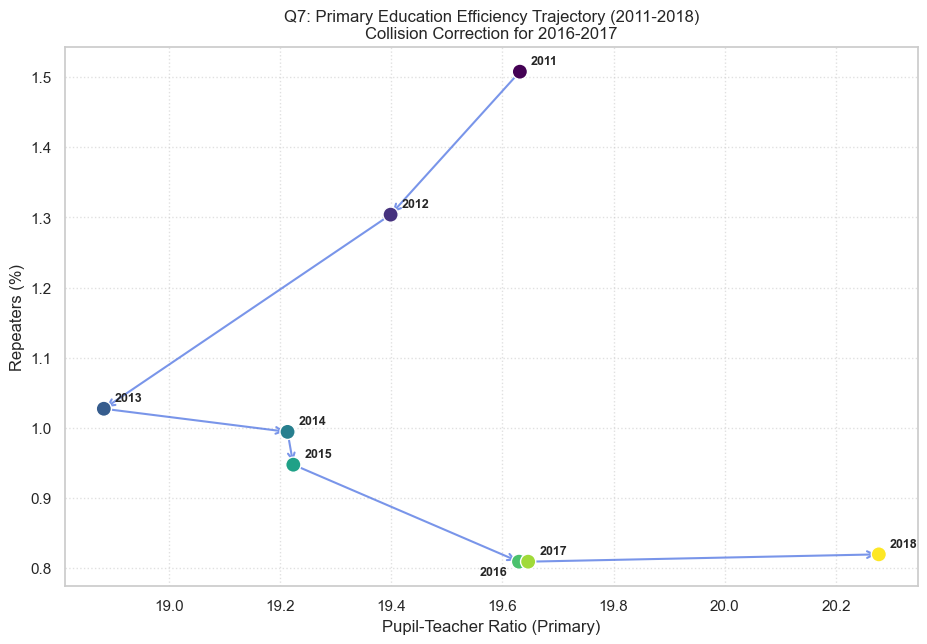

In [94]:
plot_q7(data_body)

**Graph Observations:**

[Observations to be filled in later]

**Key Conclusions:**

[Conclusions to be filled in later]

## Q8 - Poverty Threshold Analysis (2012-2022)

Question: How does the headcount ratio change when shifting the poverty definition from $3.00/day to $8.30/day across the timeline?

Graph Used: Step Line Chart

Step charts are utilized to reflect the "staircase" nature of poverty reduction data, which is often updated in distinct biennial cycles rather than continuous daily shifts. This emphasizes the discrete jumps in poverty levels when moving between different international thresholds, highlighting how many citizens are close to the lower end and vulnerable to sliding back.

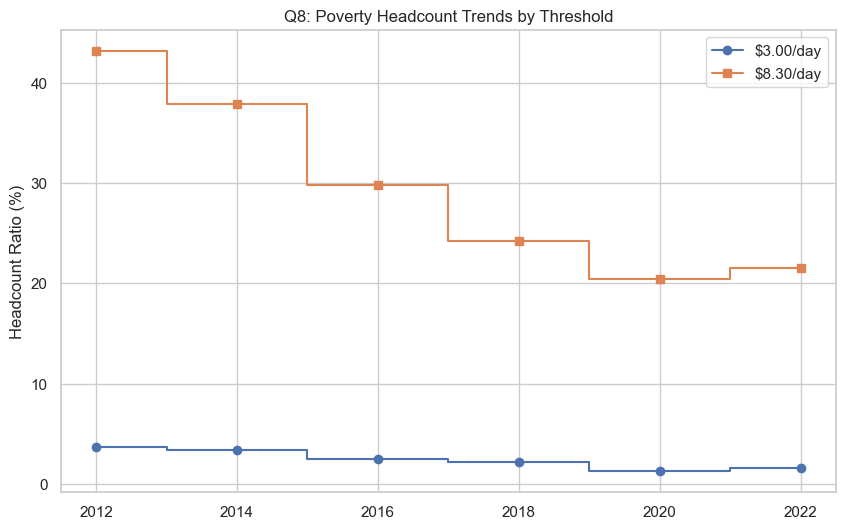

In [95]:
plot_q8(data_body)

**Graph Observations:**

[Observations to be filled in later]

**Key Conclusions:**

[Conclusions to be filled in later]

## Q9 - High-Level Attainment Composition (2023)

Question: What is the proportional breakdown of postgraduate attainment (Master's vs. Doctoral) within the 25+ population?

Graph Used: Pie Chart

A pie chart is the most effective way to show a static snapshot of a whole. Since Doctoral and Master's degrees represent the pinnacle of the educational attainment hierarchy, this chart visualizes the scarcity and relative weight of the highest-skilled labor available.

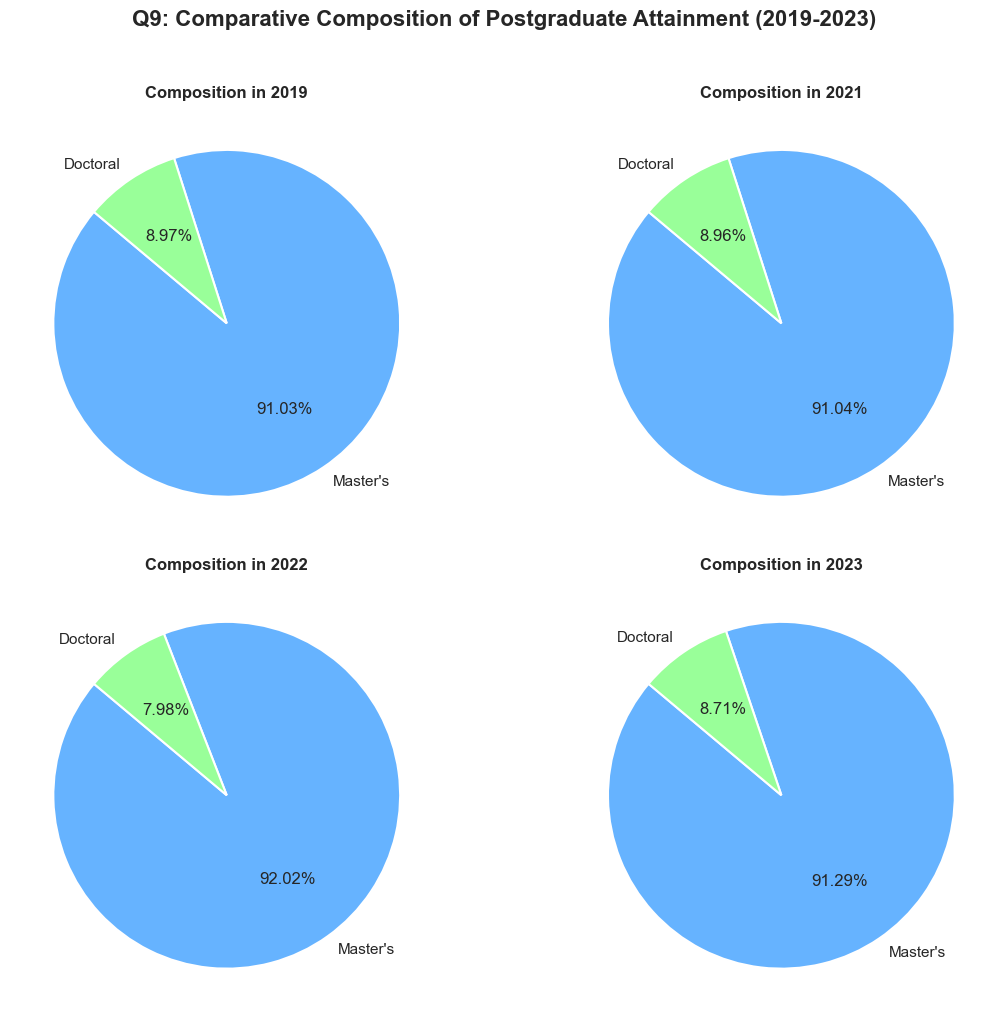

In [96]:
plot_q9(data_body)

**Graph Observations:**

[Observations to be filled in later]

**Key Conclusions:**

[Conclusions to be filled in later]

## Q10 - Savings and Environmental Cost (2011-2021)

Question: How much of Viet Nam's national savings is "lost" to particulate emission damage when comparing adjusted net savings?

Graph Used: Stacked Area Chart

By stacking the environmental damage cost on top of the net savings and scaling the axis properly, we visualize the "environmental" tax on the economy. The shaded area represents the direct subtraction from national wealth, making the invisible cost of pollution a tangible part of the financial narrative.

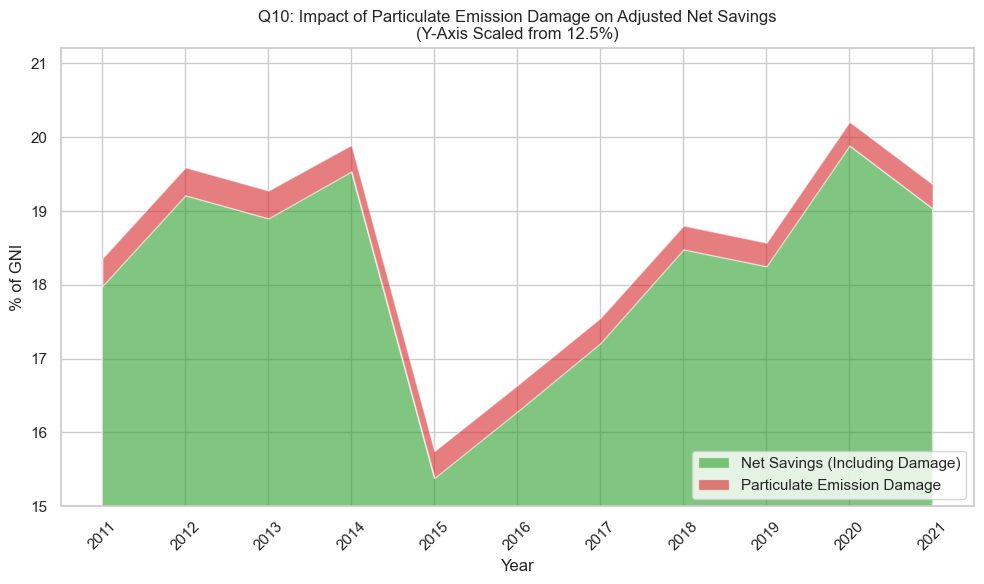

Average GNI lost to Particulate Emission Damage (2011-2021): 0.352%


In [97]:
plot_q10(data_body)

**Graph Observations:**

[Observations to be filled in later]

**Key Conclusions:**

[Conclusions to be filled in later]

## Q11 - Early Childhood Education Momentum (2011-2021)

Question: Has the growth in preprimary school enrollment kept pace with the increase in adjusted net national income?

Graph Used: Dual-Axis Line Chart

Because national income (in billions of USD) and enrollment (in %) exist on vastly different numeric scales, a dual-axis chart is mandatory. A dual-axis line chart can be used to show if the momentum of educational expansion is accelerating as fast as the economy's compound growth.

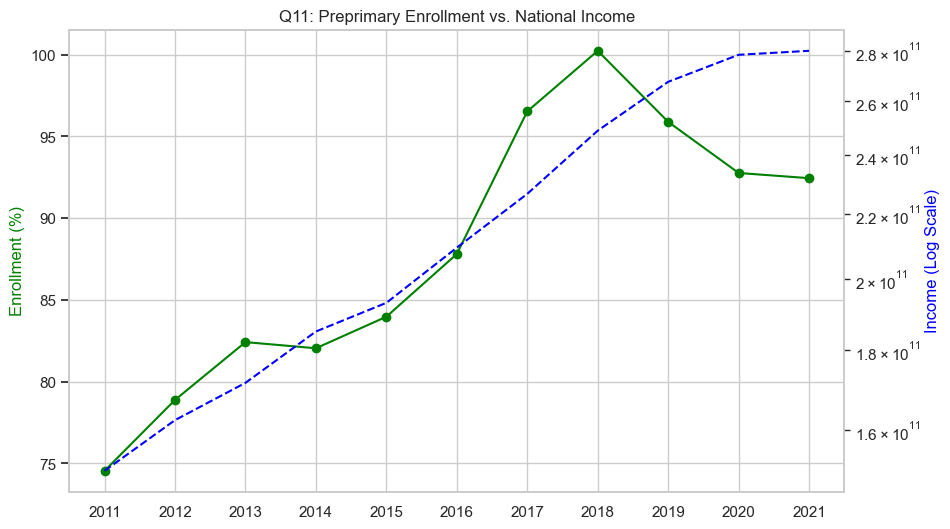

In [98]:
plot_q11(data_body)

**Graph Observations:**

[Observations to be filled in later]

**Key Conclusions:**

[Conclusions to be filled in later]

## Q12 - Multidimensional vs. Monetary Poverty (2012-2022)

Question: Does the Multidimensional Poverty index follow the same downward trajectory as the $3.00/day poverty headcount?

Graph Used: Multi-Series Line Chart

This visualization compares two distinct poverty measures—one based on monetary income thresholds and one based on deprivations in health, education, and living standards—to assess whether different poverty definitions show consistent trends.

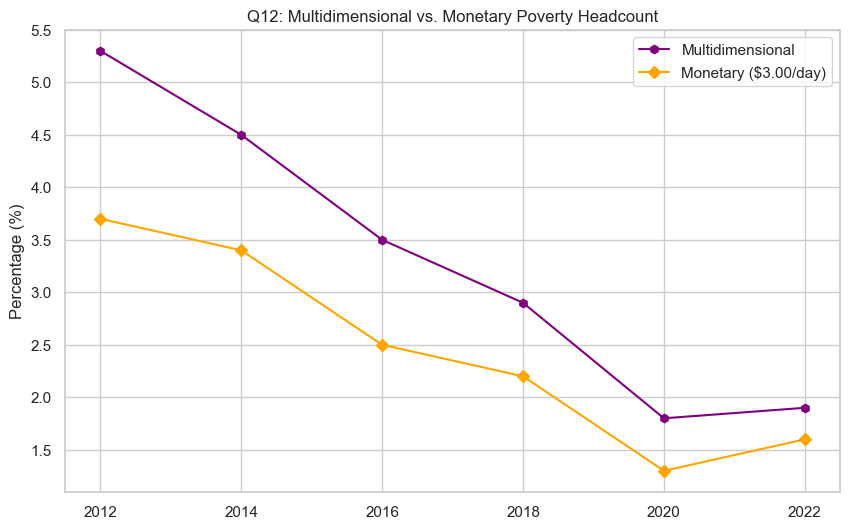

In [99]:
plot_q12(data_body)

**Graph Observations:**

[Observations to be filled in later]

**Key Conclusions:**

[Conclusions to be filled in later]